$$\Large\boxed{\text{AME 5202 Deep Learning, Even Semester 2026}}$$

$$\large\text{Theme}: \underline{\text{computational foundations of the softmax classifier}}$$

---

Load essential libraries

---

In [59]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
plt.style.use('dark_background')
%matplotlib inline
import sys
import pickle
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import nltk
from nltk.tokenize import word_tokenize
import seaborn as sns

---

Mount Google Drive folder if running Google Colab

---

In [60]:
## Mount Google drive folder if running in Colab
if('google.colab' in sys.modules):
    from google.colab import drive
    drive.mount('/content/drive', force_remount = True)
    DIR = '/content/drive/MyDrive/Colab Notebooks/MAHE/MSIS Coursework/EvenSem2026MAHE'
    DATA_DIR = DIR+'/Data/'
else:
    DATA_DIR = 'Data/'

---

**The patient data matrix with output labels and initial weight matrix**

![patient dataset](https://1drv.ms/i/s!AjTcbXuSD3I3hspfrgklysOtJMOjaA?embed=1&width=800)

---



In [61]:
## Create the patient data matrix as a constant tensor
X = torch.tensor([[72, 120, 37.3, 104, 32.5],
                  [85, 130, 37.0, 110, 14],
                  [68, 110, 38.5, 125, 34],
                  [90, 140, 38.0, 130, 26],
                  [84, 132, 38.3, 146, 30],
                  [78, 128, 37.2, 102, 12]],
                  dtype = torch.float64)
print(X)

# True output labels vector
y = np.array(['non-diabetic',
              'diabetic',
              'non-diabetic',
              'pre-diabetic',
              'diabetic',
              'pre-diabetic'])
print(y)

W = torch.tensor([[-0.1, 0.5, 0.3],
                  [0.9, 0.3, 0.5],
                  [-1.5, 0.4, 0.1],
                  [0.1, 0.1, -1.0],
                  [-1.2, 0.5, -0.8]], dtype = torch.float64,
                 requires_grad = True)
print(W)

tensor([[ 72.0000, 120.0000,  37.3000, 104.0000,  32.5000],
        [ 85.0000, 130.0000,  37.0000, 110.0000,  14.0000],
        [ 68.0000, 110.0000,  38.5000, 125.0000,  34.0000],
        [ 90.0000, 140.0000,  38.0000, 130.0000,  26.0000],
        [ 84.0000, 132.0000,  38.3000, 146.0000,  30.0000],
        [ 78.0000, 128.0000,  37.2000, 102.0000,  12.0000]],
       dtype=torch.float64)
['non-diabetic' 'diabetic' 'non-diabetic' 'pre-diabetic' 'diabetic'
 'pre-diabetic']
tensor([[-0.1000,  0.5000,  0.3000],
        [ 0.9000,  0.3000,  0.5000],
        [-1.5000,  0.4000,  0.1000],
        [ 0.1000,  0.1000, -1.0000],
        [-1.2000,  0.5000, -0.8000]], dtype=torch.float64, requires_grad=True)


---

One-hot encoding of the true output labels

---

In [62]:
# The following does not work in PyTorch
#y = torch.tensor(['non-diabetic', 'diabetic'])

# Create a 1D-numpy array of output labels (equivalent to a rank-1 tensor in
# PyTorch which itself is equivalent to a vector in pen & paper)

ohe = OneHotEncoder(sparse_output = False)
Y = ohe.fit_transform(y.reshape(-1, 1))
print(Y)

[[0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


---

Loss for each sample can be quantified using the categorical crossentropy (CCE) loss function which is defined as $$\color{yellow}{-\log(\text{predicted probability that the sample belongs its correct class})}$$

For example, consider a sample with

- true label = [$\color{yellow}{1}$ 0 0]
- predicted probabilities = [$\color{yellow}{0.05}$, 0.99, 0.05]

$\Rightarrow$ categorical crossentropy loss = $-\log(\color{yellow}{0.05}).$

---

In [63]:
y = torch.tensor([1.0, 0.0, 0.0])
a = torch.tensor([0.05, 0.99, 0.05])
-torch.log(torch.sum(y*a))

tensor(2.9957)

---

The forward propagation

---

In [64]:
# Standardize the data
sc = StandardScaler() # create a standard scaler object
print(X)
X_std = sc.fit_transform(X)
print(f'The standardized data matrix:\n{X_std}')

tensor([[ 72.0000, 120.0000,  37.3000, 104.0000,  32.5000],
        [ 85.0000, 130.0000,  37.0000, 110.0000,  14.0000],
        [ 68.0000, 110.0000,  38.5000, 125.0000,  34.0000],
        [ 90.0000, 140.0000,  38.0000, 130.0000,  26.0000],
        [ 84.0000, 132.0000,  38.3000, 146.0000,  30.0000],
        [ 78.0000, 128.0000,  37.2000, 102.0000,  12.0000]],
       dtype=torch.float64)
The standardized data matrix:
[[-0.979883   -0.70186241 -0.72380201 -0.98707429  0.89204786]
 [ 0.71858087  0.3509312  -1.24493946 -0.60498101 -1.2373567 ]
 [-1.50248727 -1.75465602  1.36074779  0.35025217  1.06470228]
 [ 1.3718362   1.40372481  0.49218537  0.66866323  0.14387869]
 [ 0.5879298   0.56148993  1.01332282  1.68757862  0.60429048]
 [-0.1959766   0.14037248 -0.8975145  -1.11443871 -1.4675626 ]]


In [65]:
y = np.array(['non-diabetic',
              'diabetic',
              'non-diabetic',
              'pre-diabetic',
              'diabetic',
              'pre-diabetic'])

In [66]:
# Standardize the data
sc = StandardScaler() # create a standard scaler object
X_std = sc.fit_transform(X)
print(f'The standardized data matrix:\n{X_std}')

# The one-hot encoded true output labels matrix
ohe = OneHotEncoder(sparse_output = False)
Y = torch.tensor(ohe.fit_transform(y.reshape(-1,1)),dtype=torch.float64)
print(f'One-hot encoded true output labels matrx:\n{Y}')

# Calculate the raw scores using the standardized data matrix
# and the weights matrix
print(f'The weights matrix:\n{W}')
Z = torch.matmul(X,W)
print(f'The raw scores matrix:\n{Z}')

# Calculate the softmax-activated scores matrix
softmax = torch.nn.Softmax(dim=1)
A = softmax(Z)
print(f'The softmax-activated scores matrix:\n{A}')

# Quantify the unhappiness w.r.t. the current set of weights

print(f'Loss = {-torch.log(torch.sum(A*Y,dim=1))}')
print(f'Avg Loss = {torch.mean(-torch.log(torch.sum(A*Y,dim=1)))}')

The standardized data matrix:
[[-0.979883   -0.70186241 -0.72380201 -0.98707429  0.89204786]
 [ 0.71858087  0.3509312  -1.24493946 -0.60498101 -1.2373567 ]
 [-1.50248727 -1.75465602  1.36074779  0.35025217  1.06470228]
 [ 1.3718362   1.40372481  0.49218537  0.66866323  0.14387869]
 [ 0.5879298   0.56148993  1.01332282  1.68757862  0.60429048]
 [-0.1959766   0.14037248 -0.8975145  -1.11443871 -1.4675626 ]]
One-hot encoded true output labels matrx:
tensor([[0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.]], dtype=torch.float64)
The weights matrix:
tensor([[-0.1000,  0.5000,  0.3000],
        [ 0.9000,  0.3000,  0.5000],
        [-1.5000,  0.4000,  0.1000],
        [ 0.1000,  0.1000, -1.0000],
        [-1.2000,  0.5000, -0.8000]], dtype=torch.float64, requires_grad=True)
The raw scores matrix:
tensor([[ 16.2500, 113.5700, -44.6700],
        [ 47.2000, 114.3000, -27.0000],
        [  6.1500, 111.9000, -72.9500],
     

---

Using PyTorch, calculate the optimal weights for the patient data matrix

---

In [76]:
# Patients data matrix
X = torch.tensor([[72, 120, 37.3, 104, 32.5],
                 [85, 130, 37.0, 110, 14],
                 [68, 110, 38.5, 125, 34],
                 [90, 140, 38.0, 130, 26],
                 [84, 132, 38.3, 146, 30],
                 [78, 128, 37.2, 102, 12]], dtype = torch.float64)
#print(f'Patient data matrix X:\n {X}') #f-string in Python

# Initial Weights matrix (trainable tensor)
W = torch.tensor([[-0.1, 0.5, 0.3],
                  [0.9, 0.3, 0.5],
                  [-1.5, 0.4, 0.1],
                  [0.1, 0.1, -1.0],
                  [-1.2, 0.5, -0.8]], dtype = torch.float64,
                 requires_grad = True)
#print(f'Weights matrix:\n {W}')

# Create a 1D-numpy array of output labels (equivalent to a rank-1 tensor in
# PyTorch which itself is equivalent to a vector in pen & paper)
y = np.array(['non-diabetic',
              'diabetic',
              'non-diabetic',
              'pre-diabetic',
              'diabetic',
              'pre-diabetic'])
# Creating a one-hot encoder object
ohe = OneHotEncoder(sparse_output = False)
# Create the one-hot encoded true output labels matrix
Y = torch.tensor(ohe.fit_transform(y.reshape(-1, 1)), dtype = torch.float64)
#print(f'One-hot encoded output labels matrix:\n {Y}')

# Standardize the data
sc = StandardScaler() # create a standard scaler object
X_std = torch.tensor(sc.fit_transform(X), dtype = torch.float64)
#print(f'The standardized data matrix:\n{X_std}')


# Define optimizer
optimizer = torch.optim.Adam([W],lr=1e-02)

# Loss function
def loss_fn(W):
  # Raw scores
  Z = torch.matmul(X_std,W)

  # Softmax-activated scores
  softmax = torch.nn.Softmax(dim=1)
  A = softmax(Z)

  # Calculate the average training loss
  L = torch.mean(-torch.log(torch.sum((A*Y),dim=1)))
  return L

# Optimization loop
num_epochs = 1000
loss_train = []
for epoch in range(num_epochs):
  # Zero out the gradients
  optimizer.zero_grad()

  # Forward propagation (loss calculation)
  loss = loss_fn(W)

  # Backward propagation and optimization
  loss.backward()
  optimizer.step()
  # Print the loss every epoch
  loss_train.append(loss.item())
  print(f'Epoch {epoch}, loss = {loss.item()}')

Epoch 0, loss = 1.2303940464309857
Epoch 1, loss = 1.1988313475082657
Epoch 2, loss = 1.167915792731229
Epoch 3, loss = 1.1376693687102686
Epoch 4, loss = 1.1081117180199922
Epoch 5, loss = 1.0792594547734682
Epoch 6, loss = 1.051125410402977
Epoch 7, loss = 1.0237179935424643
Epoch 8, loss = 0.9970410294736309
Epoch 9, loss = 0.9710944500764948
Epoch 10, loss = 0.9458757634604371
Epoch 11, loss = 0.9213816024250634
Epoch 12, loss = 0.8976086102734903
Epoch 13, loss = 0.8745535546990616
Epoch 14, loss = 0.8522130590672475
Epoch 15, loss = 0.8305833146578808
Epoch 16, loss = 0.809659899940843
Epoch 17, loss = 0.7894376848482066
Epoch 18, loss = 0.7699107683767544
Epoch 19, loss = 0.7510724162937454
Epoch 20, loss = 0.7329149877051635
Epoch 21, loss = 0.7154298533273726
Epoch 22, loss = 0.6986073148970725
Epoch 23, loss = 0.6824365365387708
Epoch 24, loss = 0.6669054973110501
Epoch 25, loss = 0.6520009713741465
Epoch 26, loss = 0.63770853937298
Epoch 27, loss = 0.6240126321543263
Epoch 2

---

Plot loss curve

---

C:\Users\Dell\AppData\Local\Temp\ipykernel_19852\3167391816.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


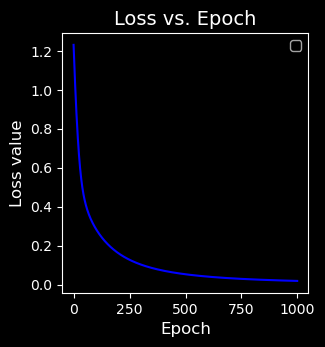

In [77]:
## Plot train loss as a function of epoch:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
fig.tight_layout(pad = 4.0)
ax.plot(loss_train, 'b')
ax.set_xlabel('Epoch', fontsize = 12)
ax.set_ylabel('Loss value', fontsize = 12)
ax.legend()
ax.set_title('Loss vs. Epoch', fontsize = 14);

In [78]:
# Print the optimized Weights matrix
print(W)

tensor([[ 2.3990, -1.0268,  1.1558],
        [-2.3522, -1.2947,  3.0253],
        [-2.3237, -1.0213,  5.3735],
        [ 2.1537, -1.6400, -6.7106],
        [-1.1512,  2.6423, -1.0289]], dtype=torch.float64, requires_grad=True)
